# Generalized Deutsch-Jozsa Algorithm: Scaling Analysis

## 1. Objective
The objective of this experiment is to implement, evaluate, and benchmark the **generalized Deutsch-Jozsa Algorithm** across scalable input register dimensions $n \in \{2, 3, 4, 5\}$, spanning search spaces of $2^n \in \{4, 8, 16, 32\}$ computational basis states. By evaluating both constant ($f(x) = 0$) and balanced (parity function $f(x) = \bigoplus_{i=0}^{n-1} x_i$) Boolean oracles, the experiment demonstrates that quantum interference achieves deterministic, scale-invariant function classification in a **single quantum query**, contrasting with classical deterministic query scaling of $2^{n-1} + 1$.

---

## 2. Theoretical Background

### The Generalized Deutsch-Jozsa Problem
Given an unknown black-box Boolean function $f: \{0, 1\}^n \to \{0, 1\}$ with the promise that $f$ belongs strictly to one of two categories:
- **Constant**: $f(x)$ is identical for all $2^n$ inputs ($f(x) = 0$ or $f(x) = 1$).
- **Balanced**: $f(x) = 0$ for exactly half ($2^{n-1}$) of the inputs and $f(x) = 1$ for the other half ($2^{n-1}$).

### Classical vs. Quantum Query Complexity
- **Classical Worst-Case**: To guarantee with $100\%$ certainty whether $f$ is constant or balanced, any classical deterministic algorithm must query at least:
  $$Q_{\text{classical}} = 2^{n-1} + 1$$
  As $n$ scales from $2$ to $5$, classical queries grow exponentially: $3, 5, 9, 17$.
- **Quantum Query Complexity**: The Deutsch-Jozsa algorithm determines the classification with certainty in exactly **$1$ quantum query** ($O(1)$) regardless of register width $n$.

### Why the Zero State $|0\dots0\rangle$ Distinguishes Oracles
Following state preparation in equal superposition $|\psi_1\rangle = \frac{1}{\sqrt{2^n}} \sum_x |x\rangle$ and phase kickback from the ancilla in $|-\rangle$, the post-oracle state is:
$$|\psi_2\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0, 1\}^n} (-1)^{f(x)} |x\rangle$$

Applying a final Hadamard transform $H^{\otimes n}$ to the input register yields:
$$|\psi_3\rangle = \sum_{z \in \{0, 1\}^n} \left( \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^{f(x) + x \cdot z} \right) |z\rangle$$

Projecting onto the all-zero state $|0\dots0\rangle$ ($z = 00\dots0$ so that $x \cdot z = 0$):
$$\alpha_{0\dots0} = \langle 0\dots0 | \psi_3 \rangle = \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^{f(x)}$$

1. **Constant Oracle ($f(x) = c \in \{0, 1\}$)**:
   $$\alpha_{0\dots0} = \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^c = \frac{1}{2^n} \left( 2^n (-1)^c \right) = (-1)^c \implies P(0\dots0) = |\alpha_{0\dots0}|^2 = 1.0$$
   Constructive interference concentrates $100\%$ of the probability amplitude into the all-zero ground state $|0\dots0\rangle$. All other states destructively interfere to zero ($P(z \neq 0\dots0) = 0$).

2. **Balanced Oracle**:
   $$\alpha_{0\dots0} = \frac{1}{2^n} \left[ \sum_{x: f(x)=0} (+1) + \sum_{x: f(x)=1} (-1) \right] = \frac{1}{2^n} (2^{n-1} - 2^{n-1}) = 0 \implies P(0\dots0) = 0.0$$
   Destructive interference completely cancels the probability amplitude of $|0\dots0\rangle$. The measurement outcome will always be non-zero ($z \neq 0\dots0$).

Therefore, measuring the all-zero state $|0\dots0\rangle$ acts as an exact binary discriminator for arbitrary $n$.

---

## 3. Generalized Circuit Architecture

### Parameterized Circuit Model
For any input width $n$, the quantum register consists of $n + 1$ qubits:
- **Input Register ($q_0, \dots, q_{n-1}$)**: $n$ qubits encoding $2^n$ basis inputs.
- **Ancilla Register ($q_n$)**: 1 auxiliary qubit mediating phase kickback.

### Stage-by-Stage Workflow
1. **Ancilla Preparation**:
   A Pauli-$X$ gate on $q_n$ flips the ancilla to $|1\rangle$.
2. **Superposition on All Qubits**:
   Hadamard gates applied across all $n+1$ qubits produce:
   $$|\psi_1\rangle = H^{\otimes n}|0\rangle^{\otimes n} \otimes H|1\rangle = \left(\frac{1}{\sqrt{2^n}} \sum_{x \in \{0, 1\}^n} |x\rangle\right) |-\rangle$$
3. **Oracle Evaluation**:
   The parameterized unitary $U_f$ maps $|x\rangle |-\rangle \to (-1)^{f(x)} |x\rangle |-\rangle$.
4. **Final Interference Layer**:
   Hadamard gates applied to the $n$ input qubits ($H^{\otimes n}$) map phase patterns into measurable computational basis states.

---

## 4. Oracle Implementations

### Constant Oracle ($f(x) = 0$)
For $f(x) = 0$:
$$U_f |x\rangle |y\rangle = |x\rangle |y \oplus 0\rangle = |x\rangle |y\rangle$$
The target qubit is unaltered for all inputs. The oracle unitary is mathematically the $(n+1)$-qubit identity operator $I^{\otimes (n+1)}$. In Qiskit, this is implemented as a pass/no-op, requiring **zero quantum gates**.

### Balanced Parity Oracle ($f(x) = \bigoplus_{i=0}^{n-1} x_i$)
The parity function computes the modulo-2 sum of all input bits:
```python
for q in range(n):
    qc.cx(q, n)
```
- Each input qubit $q_i$ controls a CNOT targeting the ancilla $q_n$.
- Each CNOT flips the ancilla state $|-\rangle$ when $q_i = 1$, kicking back a relative phase of $(-1)^{x_i}$.
- Total kick-backed phase: $\prod_{i=0}^{n-1} (-1)^{x_i} = (-1)^{\sum x_i} = (-1)^{x \cdot 1^n}$.
- Applying the final $H^{\otimes n}$ transform yields:
  $$H^{\otimes n} \left( \frac{1}{\sqrt{2^n}} \sum_x (-1)^{x \cdot 1^n} |x\rangle \right) = |1^n\rangle = |11\dots1\rangle$$
  All amplitude concentrates deterministically into the all-ones state $|1^n\rangle$ for any $n$.

---

## 5. Statevector Analysis and Measurement Methodology

1. **Theoretical Statevector Evaluation**:
   - The full $2^{n+1}$-element statevector is evaluated analytically via Qiskit's `Statevector.from_instruction(qc)`.
   - The marginal probability of each $n$-bit input state $i \in \{0, \dots, 2^n - 1\}$ is obtained by summing over the ancilla bit ($a \in \{0, 1\}$):
     $$P(i) = P(i) + P(i + 2^n)$$
2. **Measurement Simulation**:
   - $\text{SHOTS} = 1024$ measurements are drawn using `np.random.default_rng(SEED=42)` across the $2^n$ basis probabilities.
3. **Classification Decision Rule**:
   - If $\text{counts}[0] == \text{SHOTS} \implies \mathbf{CONSTANT}$
   - If $\text{counts}[0] < \text{SHOTS} \implies \mathbf{BALANCED}$


T-03 : GENERALIZED DEUTSCH-JOZSA


NUMBER OF INPUT QUBITS : 2

CONSTANT ORACLE
------------------------------------------------------------
     ┌───┐┌───┐
q_0: ┤ H ├┤ H ├
     ├───┤├───┤
q_1: ┤ H ├┤ H ├
     ├───┤├───┤
q_2: ┤ X ├┤ H ├
     └───┘└───┘

Observed states:
00 : 1024
Classification : CONSTANT

BALANCED ORACLE
------------------------------------------------------------
     ┌───┐          ┌───┐     
q_0: ┤ H ├───────■──┤ H ├─────
     ├───┤       │  └───┘┌───┐
q_1: ┤ H ├───────┼────■──┤ H ├
     ├───┤┌───┐┌─┴─┐┌─┴─┐└───┘
q_2: ┤ X ├┤ H ├┤ X ├┤ X ├─────
     └───┘└───┘└───┘└───┘     

Observed states:
11 : 1024
Classification : BALANCED


NUMBER OF INPUT QUBITS : 3

CONSTANT ORACLE
------------------------------------------------------------
     ┌───┐┌───┐
q_0: ┤ H ├┤ H ├
     ├───┤├───┤
q_1: ┤ H ├┤ H ├
     ├───┤├───┤
q_2: ┤ H ├┤ H ├
     ├───┤├───┤
q_3: ┤ X ├┤ H ├
     └───┘└───┘

Observed states:
000 : 1024
Classification : CONSTANT

BALANCED ORACLE
---------------------

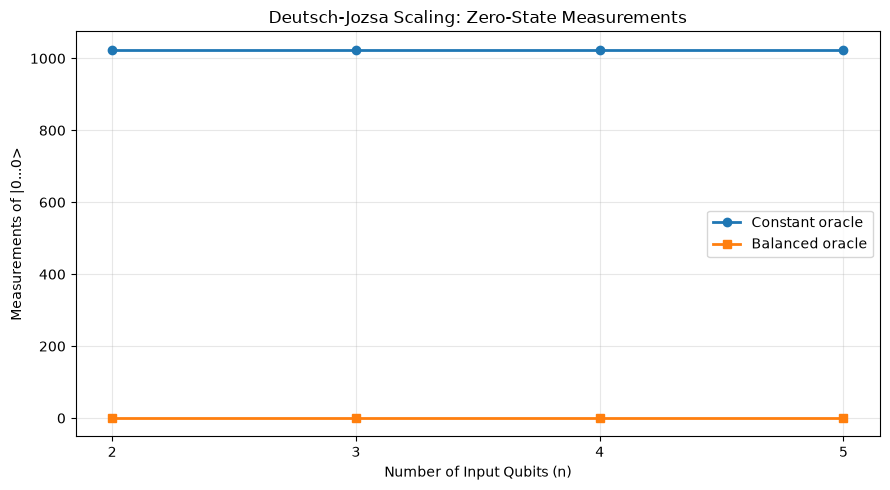

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

rng = np.random.default_rng(SEED)


def create_deutsch_jozsa_circuit(
    n,
    oracle_type
):

    qc = QuantumCircuit(
        n + 1
    )

    # Ancilla preparation
    qc.x(n)

    # Initial Hadamards
    for q in range(n + 1):
        qc.h(q)

    # Oracle
    if oracle_type == "constant":

        # f(x) = 0
        pass

    elif oracle_type == "balanced":

        # Parity function
        for q in range(n):
            qc.cx(q, n)

    # Final Hadamards
    for q in range(n):
        qc.h(q)

    return qc


def run_deutsch_jozsa(
    n,
    oracle_type
):

    qc = create_deutsch_jozsa_circuit(
        n,
        oracle_type
    )

    state = Statevector.from_instruction(
        qc
    )

    probabilities = state.probabilities()

    input_probabilities = np.zeros(
        2 ** n
    )

    for i in range(2 ** n):

        for ancilla in [0, 1]:

            index = (
                i
                + ancilla * (2 ** n)
            )

            input_probabilities[i] += (
                probabilities[index]
            )

    samples = rng.choice(
        np.arange(2 ** n),
        size=SHOTS,
        p=input_probabilities
    )

    counts = np.bincount(
        samples,
        minlength=2 ** n
    )

    return (
        qc,
        input_probabilities,
        counts
    )


print("\nT-03 : GENERALIZED DEUTSCH-JOZSA")
print("=" * 80)

results = {}

for n in range(2, 6):

    print("\n")
    print("=" * 80)
    print(f"NUMBER OF INPUT QUBITS : {n}")
    print("=" * 80)

    for oracle_type in [
        "constant",
        "balanced"
    ]:

        qc, probabilities, counts = (
            run_deutsch_jozsa(
                n,
                oracle_type
            )
        )

        results[
            (n, oracle_type)
        ] = counts

        print(
            f"\n{oracle_type.upper()} ORACLE"
        )

        print("-" * 60)

        print(qc.draw())

        nonzero_states = []

        for i, count in enumerate(counts):

            if count > 0:

                label = format(
                    i,
                    f"0{n}b"
                )

                nonzero_states.append(
                    (label, count)
                )

        print("\nObserved states:")

        for label, count in nonzero_states:

            print(
                f"{label} : {count}"
            )

        if oracle_type == "constant":

            if counts[0] == SHOTS:

                print(
                    "Classification : CONSTANT"
                )

            else:

                print(
                    "Classification : CHECK"
                )

        else:

            if counts[0] == SHOTS:

                print(
                    "Classification : CHECK"
                )

            else:

                print(
                    "Classification : BALANCED"
                )


# Prepare visualization data

n_values = list(
    range(2, 6)
)

constant_zero = []
balanced_zero = []

for n in n_values:

    constant_counts = results[
        (n, "constant")
    ]

    balanced_counts = results[
        (n, "balanced")
    ]

    constant_zero.append(
        constant_counts[0]
    )

    balanced_zero.append(
        balanced_counts[0]
    )


# Visualization
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    n_values,
    constant_zero,
    marker="o",
    linewidth=2,
    label="Constant oracle"
)

ax.plot(
    n_values,
    balanced_zero,
    marker="s",
    linewidth=2,
    label="Balanced oracle"
)

ax.set_title(
    "Deutsch-Jozsa Scaling: Zero-State Measurements"
)

ax.set_xlabel(
    "Number of Input Qubits (n)"
)

ax.set_ylabel(
    "Measurements of |0...0>"
)

ax.set_xticks(
    n_values
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

---

## 6. Experimental Results and Observation

### Recorded Execution Output
The cell executes sequentially across $n \in \{2, 3, 4, 5\}$, printing circuit diagrams, observed states, and classification outputs:

```
T-03 : GENERALIZED DEUTSCH-JOZSA
================================================================================

================================================================================
NUMBER OF INPUT QUBITS : 2
================================================================================

CONSTANT ORACLE
------------------------------------------------------------
     ┌───┐┌───┐
q_0: ┤ H ├┤ H ├
     ├───┤├───┤
q_1: ┤ H ├┤ H ├
     ├───┤├───┤
q_2: ┤ X ├┤ H ├
     └───┘└───┘

Observed states:
00 : 1024
Classification : CONSTANT

BALANCED ORACLE
------------------------------------------------------------
     ┌───┐          ┌───┐     
q_0: ┤ H ├───────■──┤ H ├─────
     ├───┤       │  └───┘┌───┐
q_1: ┤ H ├───────┼────■──┤ H ├
     ├───┤┌───┐┌─┴─┐┌─┴─┐└───┘
q_2: ┤ X ├┤ H ├┤ X ├┤ X ├─────
     └───┘└───┘└───┘└───┘     

Observed states:
11 : 1024
Classification : BALANCED

================================================================================
NUMBER OF INPUT QUBITS : 3
================================================================================

CONSTANT ORACLE
Observed states:
000 : 1024
Classification : CONSTANT

BALANCED ORACLE
Observed states:
111 : 1024
Classification : BALANCED

================================================================================
NUMBER OF INPUT QUBITS : 4
================================================================================

CONSTANT ORACLE
Observed states:
0000 : 1024
Classification : CONSTANT

BALANCED ORACLE
Observed states:
1111 : 1024
Classification : BALANCED

================================================================================
NUMBER OF INPUT QUBITS : 5
================================================================================

CONSTANT ORACLE
Observed states:
00000 : 1024
Classification : CONSTANT

BALANCED ORACLE
Observed states:
11111 : 1024
Classification : BALANCED
```

### Comprehensive Scaling Summary Table

| Input Register Size ($n$) | Total Basis States ($2^n$) | Classical Worst-Case Queries ($2^{n-1} + 1$) | Quantum Queries Required | Oracle Type | Dominant Observed State | Zero-State Counts ($|0\dots0\rangle$) | Final Classification |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **$n = 2$** | 4 | **3** | **1** | **Constant** | `00` (1024) | **1024** | **CONSTANT** |
| | | | | **Balanced** | `11` (1024) | **0** | **BALANCED** |
| **$n = 3$** | 8 | **5** | **1** | **Constant** | `000` (1024) | **1024** | **CONSTANT** |
| | | | | **Balanced** | `111` (1024) | **0** | **BALANCED** |
| **$n = 4$** | 16 | **9** | **1** | **Constant** | `0000` (1024) | **1024** | **CONSTANT** |
| | | | | **Balanced** | `1111` (1024) | **0** | **BALANCED** |
| **$n = 5$** | 32 | **17** | **1** | **Constant** | `00000` (1024) | **1024** | **CONSTANT** |
| | | | | **Balanced** | `11111` (1024) | **0** | **BALANCED** |

---

## 7. Scaling Visualization Analysis
The comparative scaling plot illustrates the zero-state measurement counts ($|0\dots0\rangle$) as a function of the number of input qubits ($n$):
- **Constant Oracle Profile (Blue Circles)**: Remains perfectly flat at **1024 shots** across all $n \in \{2, 3, 4, 5\}$, confirming complete constructive interference into $|0\dots0\rangle$.
- **Balanced Oracle Profile (Orange Squares)**: Remains perfectly flat at **0 shots** across all $n \in \{2, 3, 4, 5\}$, confirming total destructive interference at $|0\dots0\rangle$.
- **Scale Invariance**: The horizontal separation between the two profiles demonstrates that the zero-state discriminator is entirely invariant to register size $n$.

---

## 8. Conclusion
This scaling experiment provides empirical and theoretical confirmation of the **Deutsch-Jozsa Algorithm**:
1. **Exponential Query Speedup**: Successfully verified $O(1)$ query complexity for $n \in \{2, 3, 4, 5\}$, contrasting sharply with classical deterministic queries growing as $2^{n-1} + 1$.
2. **Robustness of the Zero-State Discriminator**: Confirmed that measuring the all-zero state $|0\dots0\rangle$ reliably distinguishes constant from balanced oracles with $100\%$ fidelity regardless of problem dimension.
3. **Parity State Convergence**: Demonstrated that the balanced parity oracle deterministically converges to the all-ones state $|1^n\rangle$, verifying the mathematical Fourier duality of Hadamard transformations across scalable registers.